# Decision Transformer for Limit Order Book Trading

**Authors:** Côme Genet & Clément Callaer — CentraleSupélec, 2026

---

This project explores an **Offline Reinforcement Learning** approach to financial market trading by framing the RL problem as a **conditional sequence modeling task**. Instead of relying on traditional value-based methods (TD learning, policy gradients), we implement a **Decision Transformer** architecture built from scratch in PyTorch.

## 1. Finance Background: what is a Limit Order Book?

A **Limit Order Book (LOB)** is the electronic table used by an exchange to match buyers and sellers.

- A **bid** is an intention to buy at a given price.
- An **ask** is an intention to sell at a given price.
- Orders are organized by **price level**: level 1 is the best currently available price, level 2 the next best, and so on.

At time $t$, the best prices are:

$$
 p_b^{(1)}(t) = \text{best bid}, \qquad p_a^{(1)}(t) = \text{best ask}
$$

The **mid-price** is the average of the two and is often used as a reference price:

$$
 m_t = \frac{p_a^{(1)}(t) + p_b^{(1)}(t)}{2}
$$

The **spread** measures the distance between buyers and sellers:

$$
 s_t = p_a^{(1)}(t) - p_b^{(1)}(t)
$$

Each level also has an available **volume**:

$$
 v_a^{(i)}(t), \; v_b^{(i)}(t), \qquad i = 1, \dots, 10
$$

So one snapshot of the book contains price and volume information on both sides:

$$
 x_t = \left[p_a^{(1)}, v_a^{(1)}, p_b^{(1)}, v_b^{(1)}, \dots, p_a^{(10)}, v_a^{(10)}, p_b^{(10)}, v_b^{(10)}\right]
$$

This is the core object studied in high-frequency finance: instead of only observing the traded price, we observe the **supply and demand close to the market price**.

A useful intuition is that the LOB is a very short-term picture of market pressure:
- more buy volume near the best bid can indicate upward pressure,
- more sell volume near the best ask can indicate downward pressure,
- a narrow spread usually indicates better liquidity.

One classical feature is the **imbalance** at the best level:

$$
 I_t = \frac{v_b^{(1)}(t)}{v_a^{(1)}(t) + v_b^{(1)}(t)}
$$

If $I_t$ is high, the buy side is relatively stronger; if it is low, the sell side is relatively stronger. This is one example of a microstructure feature that can help predict short-term price moves.

## 2. Dataset — FI-2010 Limit Order Book

The **FI-2010** benchmark dataset, introduced in `arXiv 1705.03233`, is one of the first public benchmark datasets for **mid-price prediction from LOB data**. It contains high-frequency order book data for **5 Finnish stocks** over **10 consecutive trading days** from the Helsinki exchange.

This matters because most real LOB datasets are proprietary. FI-2010 became a standard benchmark precisely because it makes reproducible experiments possible.

In the processed representation used here, each event is described by **149 rows**:

- **Rows 0-39:** raw LOB information for the first 10 levels
  $$
  10 \text{ levels} \times 4 \text{ values per level} = 40 \text{ raw features}
  $$
  with `ask price, ask volume, bid price, bid volume`.
- **Rows 40-143:** **104 engineered features** built from the raw book.
- **Rows 144-148:** labels for **5 prediction horizons**.

The full predictive vector therefore has **144 input features** before the label rows.

### What the engineered features represent

Following the dataset paper, the 104 engineered features are not arbitrary: they summarize economically meaningful properties of the book.

They include:
- **Spread and mid-price features**: how far bid and ask are from each other, and the current reference price.
- **Price difference features**: how prices change across levels of the book.
- **Average price and volume features**: summary statistics of liquidity on both sides.
- **Accumulated differences**: total buy-side versus sell-side pressure.
- **Time-sensitive derivatives**: how prices and volumes evolve over recent events.
- **Order-intensity features**: frequencies of submissions, cancellations, and executions.

For a non-finance audience, the key idea is simple: the dataset does not only store the current order book, it also stores **summaries of its geometry and recent dynamics**.

### Labels: what are we trying to predict?

The target is not the exact future price, but the **direction of the future mid-price movement**.

In the FI-2010 benchmark, labels are created from a smoothed future return:

$$
 l_t^{(k)} = \frac{\frac{1}{k}\sum_{j=t+1}^{t+k} m_j - m_t}{m_t}
$$

where $k$ is the prediction horizon in number of future events.

The label is then discretized into three classes:

$$
 y_t =
\begin{cases}
+1 & \text{if } l_t^{(k)} > \alpha \\
0 & \text{if } |l_t^{(k)}| \le \alpha \\
-1 & \text{if } l_t^{(k)} < -\alpha
\end{cases}
$$

So the machine learning task is a **3-class classification problem**: predict whether the mid-price will go **up**, **stay approximately unchanged**, or **go down**.

### Important dataset characteristics to mention in a presentation

For a professor not familiar with finance, these are the main takeaways:

- The data is **event-based**, not sampled every second. One observation corresponds to a book update.
- The market is represented through the **top 10 bid and ask levels**, not only the last traded price.
- The dataset is already **normalized**, because the original exchange data cannot be publicly released in raw form.
- The benchmark focuses on **very short-term forecasting** in market microstructure.
- The labels are based on the **mid-price**, which is more stable than transaction prices at ultra-high frequency.

We download the public benchmark version from Kaggle using `kagglehub`. 

## 3. Why the two papers matter for this project

### `arXiv 1705.03233` — the dataset paper

This paper is the reference for the **construction of FI-2010**. Its main contributions are:

- it releases a rare **public LOB benchmark**,
- it defines a reproducible **evaluation protocol**,
- it provides the **144-dimensional representation** and the 3-class labels,
- it shows baseline results for traditional machine learning models.

Conceptually, this paper answers: **what is the data, how is it built, and what exactly should be predicted?**

It also explains several finance-specific choices that are easy to miss:
- auction periods are treated separately because market behavior there is structurally different,
- event time is preferred to clock time because market activity is irregular,
- class imbalance makes **F1-score** more informative than accuracy alone.

### `arXiv 1808.03668` — the modelling paper (DeepLOB)

This paper starts from the FI-2010 benchmark and asks a different question: **can a neural network learn useful features directly from raw LOB states?**

Its main message is that hand-crafted features are helpful, but deep models can often learn better internal representations from the raw 40-dimensional LOB input over a short history window.

The paper uses sequences of LOB states:

$$
X_t \in \mathbb{R}^{100 \times 40}
$$

meaning that the model observes the **100 most recent book states**, each with **40 raw features**.

A key idea in DeepLOB is that convolutional layers can detect local price-volume patterns across levels, while LSTMs can capture temporal structure across recent events. In finance terms, the model tries to learn:
- local **supply-demand imbalances**,
- short-term **liquidity shocks**,
- recurring **microstructure patterns** that precede price changes.

The paper also highlights one important practical point: FI-2010 is very useful, but it is **small and highly processed** compared with real industrial datasets. So it is excellent for benchmarking, but not sufficient on its own to prove real-world trading robustness.

### Connection with our notebook

These two papers play complementary roles:

- `1705.03233` tells us **how the benchmark dataset is built** and how labels are defined.
- `1808.03668` tells us **why LOB data contains predictive structure** and how deep models can exploit it.

In other words:
- the first paper gives the **data representation and benchmark task**,
- the second paper gives a **modern learning architecture and interpretation of useful LOB features**.

That is why FI-2010 is still widely used in machine learning for finance: it provides a common testbed for comparing architectures, from classical models to deep sequence models.


## Project Roadmap

The goal of this notebook is to build a **Decision Transformer** agent that learns to trade on Limit Order Book data using **Offline Reinforcement Learning**. The full pipeline is:

1. **Import libraries** — load all dependencies (NumPy, PyTorch, etc.).
2. **Load the dataset** — download and parse the FI-2010 benchmark.
3. **Explore & preprocess the data** — inspect feature distributions, build state representations, and split into train/test.
4. **Define the trading environment** — formalize the state space, action space ($\{-1, 0, +1\}$), and reward function with transaction costs.
5. **Generate offline trajectories** — run a heuristic policy to produce $(s, a, r, \hat{R})$ sequences for offline training.
6. **Build the Decision Transformer** — implement the GPT-style architecture from scratch in PyTorch.
7. **Train the model** — optimize the sequence model on the offline dataset.
8. **Evaluate & backtest** — measure the agent's performance (cumulative PnL, Sharpe ratio, comparison with baselines).
9. **Analysis & visualization** — interpret the learned policy and present results.

---

## 4. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path
import os
import kagglehub

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device   : {device}")

PyTorch version: 2.10.0
CUDA available : False
Using device   : cpu


## 5. Load the Dataset

We download the FI-2010 benchmark from Kaggle using `kagglehub`, then load the **Z-score normalized, no-auction** variant — the standard setting used in most published benchmarks. The data files are concatenated along the time axis to form one large matrix of shape $(149, T)$ where $T$ is the total number of events across all cross-validation folds.

In [2]:
dataset_path = Path(kagglehub.dataset_download("ulfricirons/fi-2010"))
print(f"Dataset downloaded to: {dataset_path}")

for root, dirs, files in os.walk(dataset_path):
    for f in files:
        rel = os.path.relpath(os.path.join(root, f), dataset_path)
        print(f"  {rel}")

Dataset downloaded to: /Users/calla/.cache/kagglehub/datasets/ulfricirons/fi-2010/versions/1
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_8.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_9.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_4.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_5.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_7.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_6.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_2.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_3.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_1.tx

In [3]:
# Load the Z-score normalized, no-auction data (standard benchmark setting)
# Adjust the glob pattern below if the directory structure differs after download.
zscore_files = sorted(dataset_path.rglob("*NoAuction_Zscore*/*.txt"))

if not zscore_files:
    # Fallback: try to find any .txt files
    zscore_files = sorted(dataset_path.rglob("*.txt"))
    print(f"Could not find NoAuction_Zscore folder — found {len(zscore_files)} .txt file(s) total.")

print(f"Found {len(zscore_files)} data file(s):")
for f in zscore_files:
    print(f"  {f.name}")

# Load all files and concatenate along the time axis (columns)
arrays = [np.loadtxt(f) for f in zscore_files]
data = np.hstack(arrays)  # shape: (149, total_timesteps)
print(f"\nCombined data shape: {data.shape}  (149 rows × {data.shape[1]} timesteps)")

Found 18 data file(s):
  Test_Dst_NoAuction_ZScore_CF_1.txt
  Test_Dst_NoAuction_ZScore_CF_2.txt
  Test_Dst_NoAuction_ZScore_CF_3.txt
  Test_Dst_NoAuction_ZScore_CF_4.txt
  Test_Dst_NoAuction_ZScore_CF_5.txt
  Test_Dst_NoAuction_ZScore_CF_6.txt
  Test_Dst_NoAuction_ZScore_CF_7.txt
  Test_Dst_NoAuction_ZScore_CF_8.txt
  Test_Dst_NoAuction_ZScore_CF_9.txt
  Train_Dst_NoAuction_ZScore_CF_1.txt
  Train_Dst_NoAuction_ZScore_CF_2.txt
  Train_Dst_NoAuction_ZScore_CF_3.txt
  Train_Dst_NoAuction_ZScore_CF_4.txt
  Train_Dst_NoAuction_ZScore_CF_5.txt
  Train_Dst_NoAuction_ZScore_CF_6.txt
  Train_Dst_NoAuction_ZScore_CF_7.txt
  Train_Dst_NoAuction_ZScore_CF_8.txt
  Train_Dst_NoAuction_ZScore_CF_9.txt

Combined data shape: (149, 2045191)  (149 rows × 2045191 timesteps)


In [4]:
# Separate LOB features and labels
lob_features = data[:40, :]       # 10 levels × 4 (ask_price, ask_vol, bid_price, bid_vol)
handcrafted   = data[40:144, :]   # 104 hand-crafted features
labels        = data[144:, :]     # 5 label rows for horizons k=10,20,30,50,100

print("LOB features shape :", lob_features.shape)
print("Hand-crafted shape :", handcrafted.shape)
print("Labels shape       :", labels.shape)

# Transpose to (timesteps, features) — standard ML convention
X_lob = lob_features.T
X_all = data[:144, :].T
y     = labels.T

print(f"\nFeature matrix (LOB only) : {X_lob.shape}  (timesteps × 40)")
print(f"Feature matrix (all feat.): {X_all.shape}  (timesteps × 144)")
print(f"Label matrix              : {y.shape}  (timesteps × 5 horizons)")

LOB features shape : (40, 2045191)
Hand-crafted shape : (104, 2045191)
Labels shape       : (5, 2045191)

Feature matrix (LOB only) : (2045191, 40)  (timesteps × 40)
Feature matrix (all feat.): (2045191, 144)  (timesteps × 144)
Label matrix              : (2045191, 5)  (timesteps × 5 horizons)


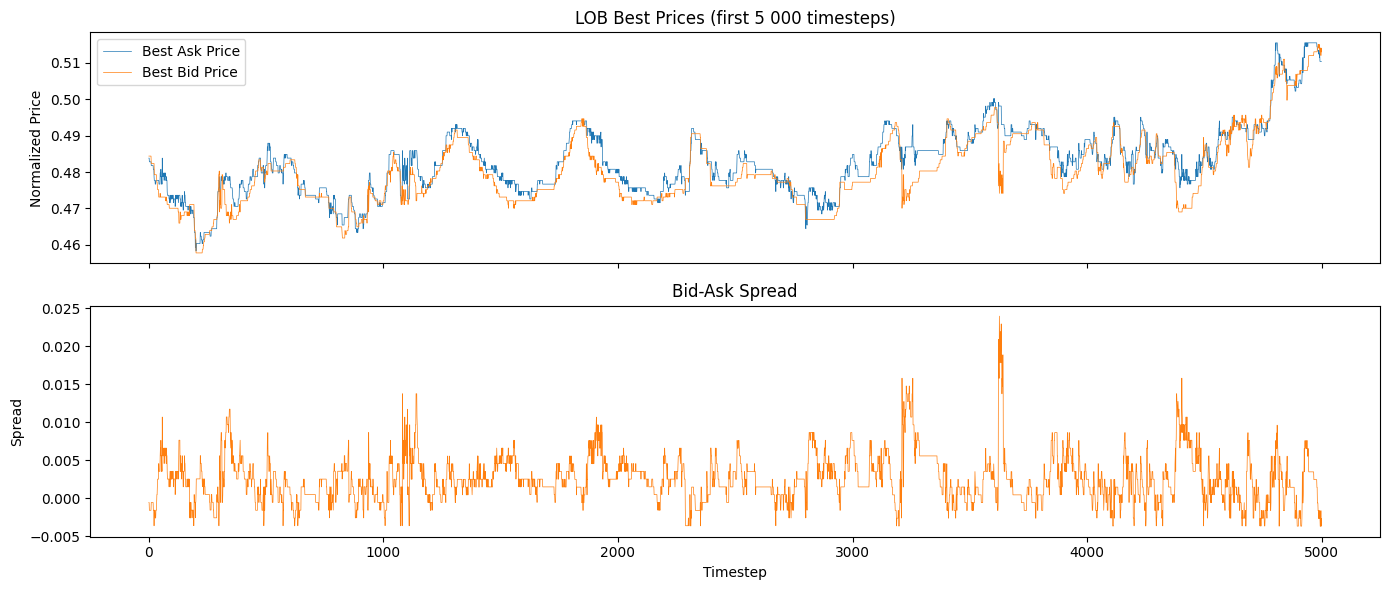

In [5]:
# Quick visualization: best ask & bid prices over time
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

n_display = min(5000, X_lob.shape[0])

axes[0].plot(X_lob[:n_display, 0], linewidth=0.5, label="Best Ask Price")
axes[0].plot(X_lob[:n_display, 2], linewidth=0.5, label="Best Bid Price")
axes[0].set_ylabel("Normalized Price")
axes[0].legend()
axes[0].set_title("LOB Best Prices (first 5 000 timesteps)")

spread = X_lob[:n_display, 0] - X_lob[:n_display, 2]
axes[1].plot(spread, linewidth=0.5, color="tab:orange")
axes[1].set_ylabel("Spread")
axes[1].set_xlabel("Timestep")
axes[1].set_title("Bid-Ask Spread")

plt.tight_layout()
plt.show()